# Часть Б: YOLOv8n и YOLOv8s

Этот ноутбук читает выполненные эксперименты, не запускает обучение и не подбирает настройки по test. Разбиение А: 522 train / 160 validation / 90 test.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/b/evaluation.yaml").exists())
validation = ROOT / "reports/b/validation"
report = json.loads((validation / "comparison.json").read_text(encoding="utf-8"))
assert report["split"] == "val" and not report["test_evaluated"]


## Сопоставимые условия

YOLOv8s повторяет фактический baseline А: 20 эпох, 640, batch=4, seed=42, AdamW, та же аугментация. Скорость всех моделей измеряется заново на одной машине. Один seed не устанавливает статистическую значимость разницы.

In [2]:
import yaml
config = yaml.safe_load((ROOT / "configs/b/yolov8s_baseline.yaml").read_text(encoding="utf-8"))
display(pd.Series(config["train"]))
display(pd.Series(report["environment"]["packages"]))


epochs               20
imgsz               640
batch                 4
workers               0
patience             15
optimizer         AdamW
lr0               0.001
lrf                0.01
weight_decay     0.0005
warmup_epochs       3.0
cos_lr             True
close_mosaic         10
fraction            1.0
cache               ram
amp               False
dtype: object

ultralytics         8.3.228
torch           2.6.0+cu124
torchvision    0.21.0+cu124
numpy                 2.2.6
PyYAML                6.0.3
Pillow               11.3.0
dtype: object

## Качество и скорость на validation

Precision/Recall в таблице — показатели Ultralytics в её точке максимального F1. Для mAP используется conf=0.001. Рабочий порог выбирается отдельно по micro F1 при IoU=0.5. Время после прогрева включает preprocessing, inference, NMS и получение рамок, но не чтение файла, загрузку весов или рисование.

,model,precision,recall,mAP50,mAP50_95,confidence,operating_F1,initial_sequential_mean_ms,device,alternating_mean_ms,network_mean_ms
0,a_n_baseline_20,0.6876,0.6432,0.6678,0.3359,0.3,0.6696,107.7528,NVIDIA GeForce RTX 3050 Laptop GPU,86.6796,14.3505
1,a_n_aug_20,0.7000,0.5923,0.6351,0.2809,0.3,0.6528,103.7052,NVIDIA GeForce RTX 3050 Laptop GPU,86.4381,14.1202
2,b_s_baseline_20,0.7833,0.6535,0.7226,0.3913,0.4,0.7125,95.6761,NVIDIA GeForce RTX 3050 Laptop GPU,104.5029,32.1441


Дополнительный замер чередует модели на каждом кадре и хранит один RGB-снимок за раз; общий conf=0.25. Он уменьшает влияние порядка и давления на RAM. Первичный последовательный замер сохранён отдельно.

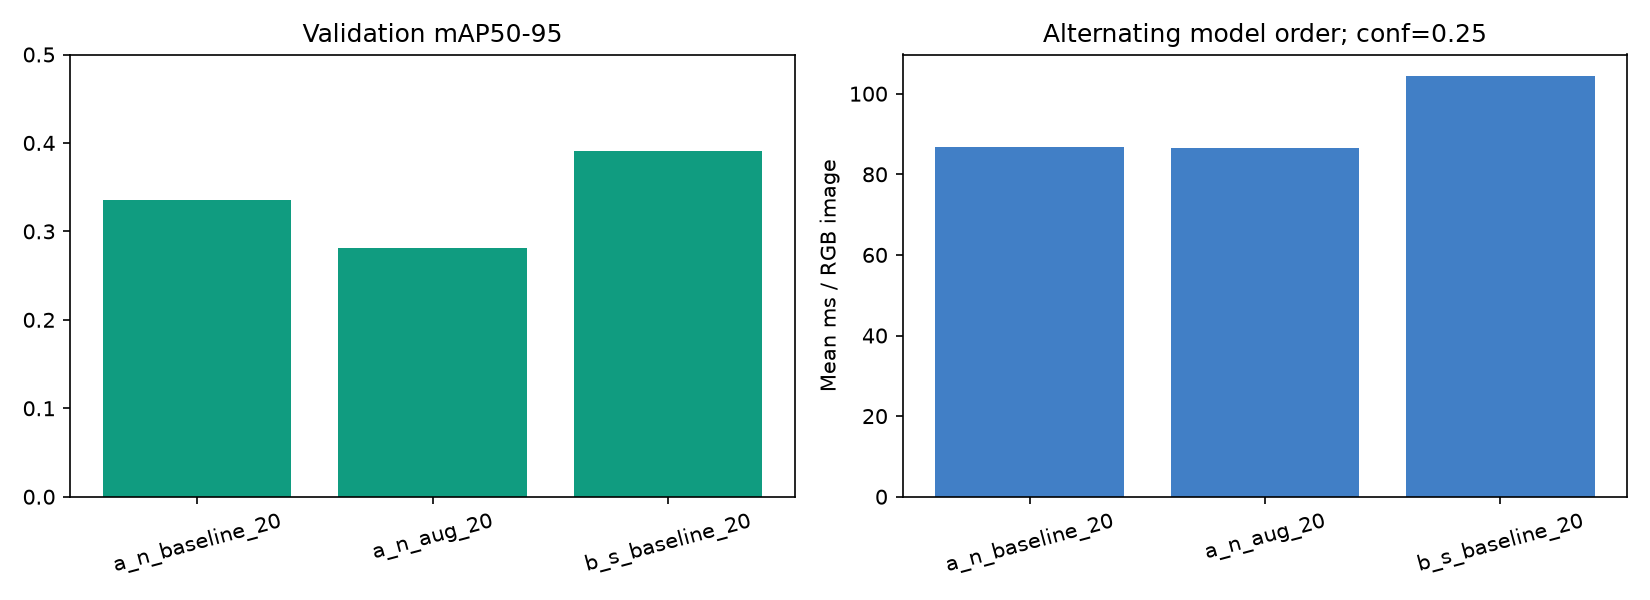

In [3]:
table = pd.DataFrame([{"model": row["name"], **row["metrics"],
    "confidence": row["operating_point"]["conf"], "operating_F1": row["operating_point"]["f1"],
    "initial_sequential_mean_ms": row["latency"]["mean_ms"],
    "device": row["latency"]["device_name"]} for row in report["models"]])
latency = json.loads((ROOT / "reports/b/latency.json").read_text(encoding="utf-8"))
table["alternating_mean_ms"] = table["model"].map(lambda name: latency["models"][name]["wall_ms"]["mean_ms"])
table["network_mean_ms"] = table["model"].map(lambda name: latency["models"][name]["inference"]["mean_ms"])
display(table.round(4))
display(Markdown("Дополнительный замер чередует модели на каждом кадре и хранит один RGB-снимок за раз; общий conf=0.25. Он уменьшает влияние порядка и давления на RAM. Первичный последовательный замер сохранён отдельно."))
display(Image(filename=str(ROOT / "reports/b/quality_speed.png")))


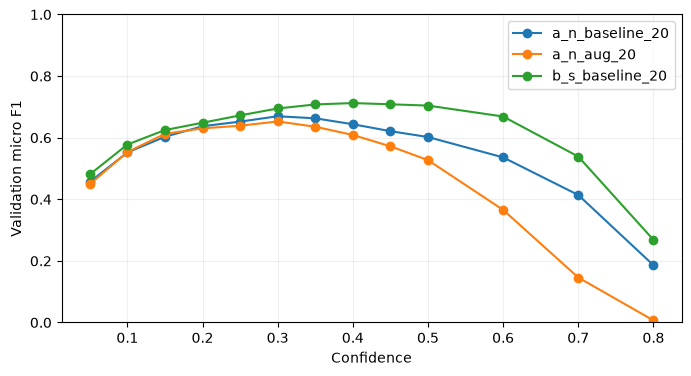

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
for row in report["models"]:
    curve = pd.DataFrame(row["confidence_curve"])
    ax.plot(curve["conf"], curve["f1"], marker="o", label=row["name"])
ax.set(xlabel="Confidence", ylabel="Validation micro F1", ylim=(0, 1))
ax.legend(); ax.grid(alpha=0.2); plt.show()


## Выбор до итоговой оценки

Критерий выбора модели — максимальный validation mAP50–95. При равном F1 порог выбирается по Precision и затем по большему порогу. Настройки, хэш весов и версия данных фиксируются до test.

In [5]:
selection = json.loads((validation / "selection.json").read_text(encoding="utf-8"))
display(pd.Series({k: selection[k] for k in ["name", "conf", "criterion", "weights_sha256", "dataset_identity"]}))


name                                                  b_s_baseline_20
conf                                                              0.4
criterion                               max mAP50_95; tie: model name
weights_sha256      1f193df59d8893d004fa6d8999b5b00f737fbb4792fbd5...
dataset_identity    8956a20832a85f145ec0f1c13bb5070273b674c52b12ee...
dtype: object

## Итоговый test

Ниже только чтение уже выполненного финального отчёта. Эти показатели не используются для выбора другой модели или порога.

In [6]:
test = json.loads((ROOT / "reports/b/test/comparison.json").read_text(encoding="utf-8"))
assert test["split"] == "test"
display(pd.DataFrame([{"model": row["name"], **row["metrics"], **{f"operating_{k}": v for k,v in row["operating_point"].items()}} for row in test["models"]]).round(4))


,model,precision,recall,mAP50,mAP50_95,operating_conf,operating_tp,operating_fp,operating_fn,operating_precision,operating_recall,operating_f1
0,b_s_baseline_20,0.8293,0.6769,0.7968,0.4496,0.4,216,38,109,0.8504,0.6646,0.7461


## Ограничения

Группы получены из имён файлов и не подтверждают независимость мест съёмки. Нет отдельных чистых сцен. Проверка на UAVVaste не устанавливает качество на море, побережье или спутниковых снимках. Подробные выводы: `reports/b/RESULTS.md`.